In [1]:
import numpy as np
import cmath as cm
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter("ignore")

## Exercise 1(Solved,Warm up): Plotting the Hertzsprung-Russell diagram of a star

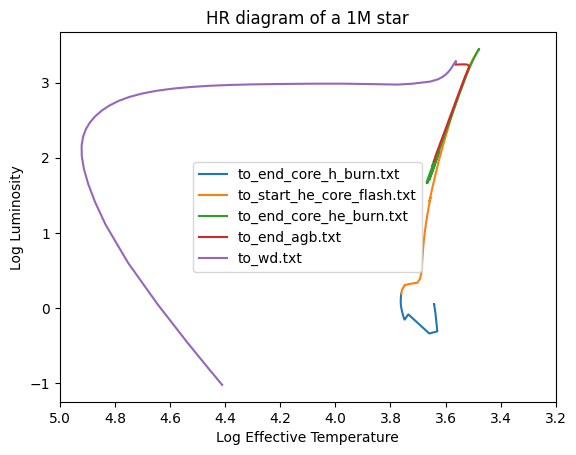

In [4]:
#Don't change anything in this cell
files=["to_end_core_h_burn.txt","to_start_he_core_flash.txt",
       "to_end_core_he_burn.txt","to_end_agb.txt","to_wd.txt"]
plt.title("HR diagram of a 1M star")
plt.xlabel("Log Effective Temperature")
plt.ylabel("Log Luminosity")
for i in files:
  teff,l=[],[]
  with open(i, 'r') as file:
    for line in file:
      parts = line.split()
      teff.append(float(parts[0]))
      l.append(float(parts[1]))
  plt.plot(teff,l,label=i)
  plt.xlim(5,3.2)
  plt.legend()
plt.show()

## Exercise 2: Discrete Fourier Transform of a Noisy Signal

In [5]:
filename='ndshm.dat'
#filepath=....(If there)
#filename=filepath+filename
time,amplitude=[],[]
with open(filename, 'r') as file:
    for line in file:
      parts = line.split()
      time.append(float(parts[0]))
      amplitude.append(float(parts[1]))
lent=len(time)


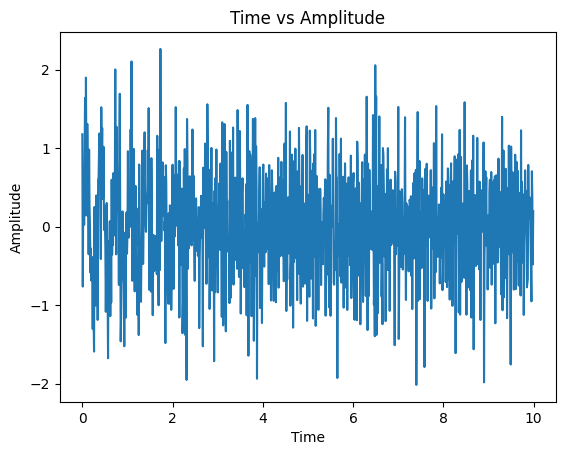

In [20]:
# Exercise 2a: Plot Time vs Amplitude, make sure to label the axis

plt.plot(time, amplitude)
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.title("Time vs Amplitude")
plt.show()


In [6]:
freq=time.copy()
for j in range(lent):
  freq[j]=(j-lent/2)/(lent*0.01)
famp=[]
fsq=[]
for j in range(lent):
  ft=0+0j
  for k in range(lent):
    ft=ft+amplitude[k]*cm.exp(2*np.pi*1j*(j-lent/2)*k/lent)
  famp.append(ft)
  fsq.append(np.abs(ft)**2)

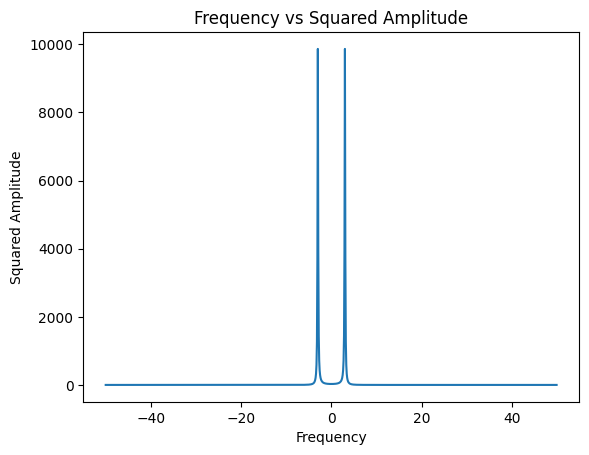

In [21]:
#Exercise 2b:Plot the frequency (freq variable) and square amplitude (fsq)

plt.plot(freq, fsq)
plt.xlabel("Frequency")
plt.ylabel("Squared Amplitude")
plt.title("Frequency vs Squared Amplitude")
plt.show()


In [8]:
for j in range(lent):
  if freq[j]<=-10 or freq[j] >=10:
    famp[j]=0
    fsq[j]=0

In [22]:
#Exercise 2c:Plot the frequency (freq variable) and square amplitude (fsq)

for j in range(lent):
    if freq[j]<-10 or freq[j]>10:
        famp[j]=0
        fsq[j]=0


In [23]:
modamp = []
for k in range(lent):
    ft = 0
    for j in range(lent):
        ft=ft+famp[j]*cm.exp(-2j * np.pi * (j-lent/2) * k / lent)
    modamp.append(ft / lent)

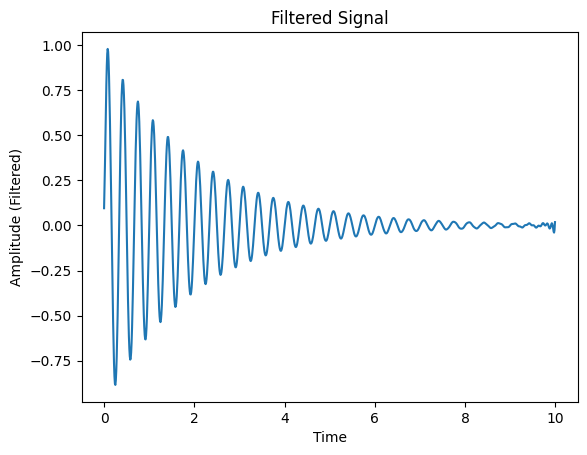

In [24]:
#Exercise 2d:Plot the time (freq variable) and modified amplitude (modamp)

plt.plot(time, modamp)
plt.xlabel("Time")
plt.ylabel("Amplitude (Filtered)")
plt.title("Filtered Signal")
plt.show()


## Exercise 3: Plotting of Electric potential for different systems

### Poisson Solvers

In [12]:
def sorgspoisson(w,Pn,Rho,delx,dely):
  sum=0
  for i in range(Pn.shape[1]-1):
    for j in range(Pn.shape[0]-1):
      o=Pn[i,j]
      Pn[i,j]=(1-w)*Pn[i,j]+w*(((Pn[i+1][j]+Pn[i-1][j])/delx**2+(Pn[i][j+1]+Pn[i][j-1])/dely**2-Rho[i,j])/(2/delx**2+2/dely**2))

  sum=sum+(o-Pn[i,j])**2
  ne=np.sqrt(sum)
  return Pn,ne

In [16]:
#System 1
Rho = np.zeros((100,100))
P = np.zeros((100,100))
for i in range(25,75):
    Rho[25][i] = 1
    Rho[75][i] = -1

T = 1000
tol = 1e-9

for i in range(T):
    P, ne = sorgspoisson(1.8, P, Rho, 0.1, 0.1)
    if ne < tol:
        break


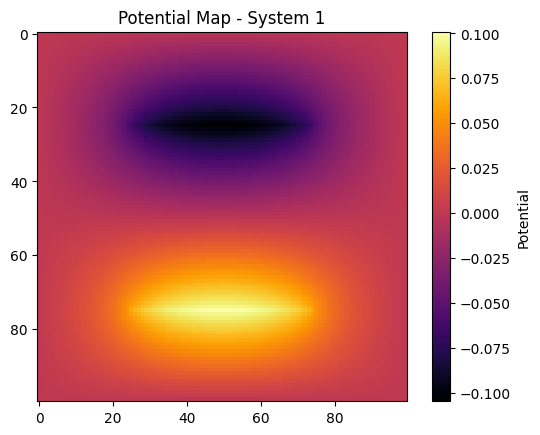

In [25]:
#3a) Plot the potential map given in P

plt.imshow(P, cmap="inferno")
plt.colorbar(label="Potential")
plt.title("Potential Map - System 1")
plt.show()


In [26]:
Rho=np.zeros((100,100))
P=np.zeros((100,100))
Rho[45][50]=1
Rho[65][50]=-1


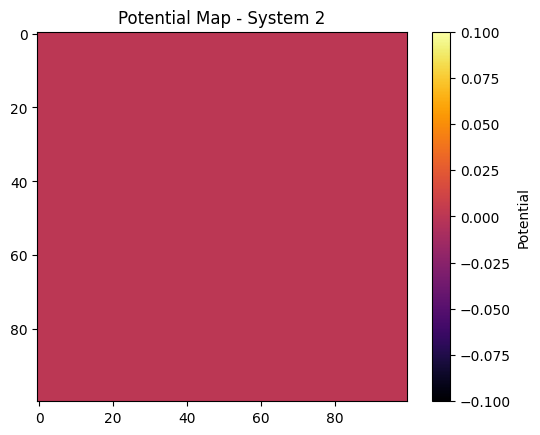

In [27]:

#3b) Plot the potential map given in P
plt.imshow(P, cmap="inferno")
plt.colorbar(label="Potential")
plt.title("Potential Map - System 2")
plt.show()
